# Биграммы

In [1]:
import os
import csv
from string import punctuation
from nltk.tokenize import sent_tokenize
from pymorphy2 import MorphAnalyzer
import matplotlib.pyplot as plt
import numpy as np

morph = MorphAnalyzer()
punctuation+='«»' # Добавим кавычки, так как их в списке нет

Разбиваем тексты на предложения, переводим в нижний регистр, убираем пунктуацию и записываем в словарь

# Филология

In [2]:
with open('metatable.csv', encoding='utf8') as file:
    meta = csv.DictReader(file, delimiter=';')
    phil_texts = {}
    for row in meta:
        if row['специальность'] == 'филология' and row['мп'] == '1':
            file = row['\ufeffid']
            with open('./texts/' + file + '.txt', encoding='utf8') as f:
                text = f.read()
                text = sent_tokenize(text)
                for i in range(len(text)):
                    text[i] = ' '.join([word.lower().strip(punctuation).strip() for word in text[i].split()])
                phil_texts[file] = text

## Лемматизация

In [3]:
for number, text in phil_texts.items():
    for i in range(len(text)):
        lemmas = []
        for word in text[i].split(' '):
            ann = morph.parse(word)[0]
            lemmas.append(ann.normal_form)
        text[i] = ' '.join(lemmas)

## Без стоп-слов

In [4]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import copy

stops = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vlada\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
filtered_phil_texts = copy.deepcopy(phil_texts)

In [6]:
for number, text in filtered_phil_texts.items():
    for i in range(len(text)):
        filtered = []
        for word in text[i].split(' '):
            if word not in stops:
                filtered.append(word)
        text[i] = ' '.join(filtered)

In [7]:
filt_bigramms_per_text = {}
filt_bigramms_all = {}
for number, text in filtered_phil_texts.items():
    filt_bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if filt_bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        filt_bigramms_per_text[number][' '.join(bigramm)] += 1
                        filt_bigramms_all[' '.join(bigramm)] += 1

                    elif filt_bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        filt_bigramms_all[' '.join(bigramm)] += 1
                        filt_bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        filt_bigramms_all[' '.join(bigramm)] = 1

In [8]:
filt_bigramms_all = {k: v for k, v in sorted(filt_bigramms_all.items(), key=lambda item: item[1], reverse=True)}

# Визуализация

График с абсолютными числами

In [9]:
filt_ind = list(filt_bigramms_all.keys())[:20]
filt_val = list(filt_bigramms_all.values())[:20]

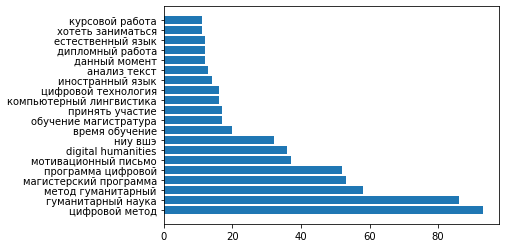

<Figure size 14400x14400 with 0 Axes>

In [10]:
plt.barh(filt_ind, filt_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

## Выкидываем слова, нграммы с которыми нам неинтересны 

In [11]:
flit2_phil_texts = copy.deepcopy(filtered_phil_texts)

Слова, которые мы считаем лишними для нашего исследования

In [20]:
words = ['ниу', 'вшэ', 'цифровой', 'гуманитарный', 'магистерский', 'письмо', 'школа', 'магистратура', 'humanities', 'программа', 'метод', 'экономика', 'мотивационный', 'name', 'job', 'education', 'project']

In [21]:
for number, text in flit2_phil_texts.items():
    for i in range(len(text)):
        filtered = []
        for word in text[i].split(' '):
            if word not in words:
                filtered.append(word)
        text[i] = ' '.join(filtered)

In [22]:
filt2_bigramms_per_text = {}
filt2_bigramms_all = {}
for number, text in flit2_phil_texts.items():
    filt2_bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if filt2_bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        filt2_bigramms_per_text[number][' '.join(bigramm)] += 1
                        filt2_bigramms_all[' '.join(bigramm)] += 1

                    elif filt2_bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        filt2_bigramms_all[' '.join(bigramm)] += 1
                        filt2_bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        filt2_bigramms_all[' '.join(bigramm)] = 1

In [23]:
filt2_bigramms_all = {k: v for k, v in sorted(filt2_bigramms_all.items(), key=lambda item: item[1], reverse=True)}

### Визуализация

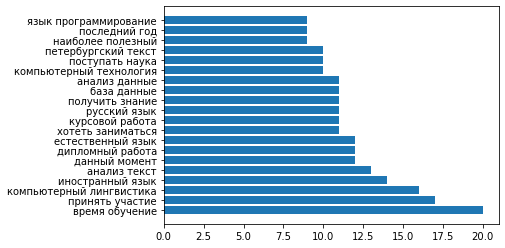

<Figure size 14400x14400 with 0 Axes>

In [24]:
filt2_ind = list(filt2_bigramms_all.keys())[:20]
filt2_val = list(filt2_bigramms_all.values())[:20]

plt.barh(filt2_ind, filt2_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

In [25]:
with open('phil.csv', 'w', encoding='utf8') as file:
    w = csv.writer(file)
    for i in range(20):
        w.writerow((filt2_ind[i], filt2_val[i]))

Самые непопулярные

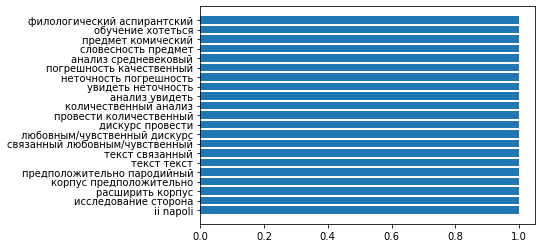

<Figure size 14400x14400 with 0 Axes>

In [17]:
filt2_ind = list(filt2_bigramms_all.keys())[-21:]
filt2_val = list(filt2_bigramms_all.values())[-21:]

plt.barh(filt2_ind, filt2_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()